### Investigate the remap2022 dataset

In [2]:
import pandas as pd

In [2]:
# read the remap file and check how many tfbs regions per TFBS exist
remap_path = "/home/kisa/coding/80K_MPRA/remap_chipseq_pia/remap2022_nr_macs2_hg38_v1_0.bed.gz"

remap_df = pd.read_csv(remap_path, sep="\t", header=None, compression="gzip")


In [3]:
remap_df

,0,1,2,3,4,5,6,7,8
0,chr1,9829,10459,SMARCA4:HeLa,1,.,10084,10085,"224,84,252"
1,chr1,9880,10389,RELB:GM12878,1,.,10091,10092,"252,168,56"
2,chr1,9883,10270,MLLT1:GM12878,1,.,10088,10089,"140,28,84"
3,chr1,9884,10289,ZBTB10:HEK293,1,.,10106,10107,"70,67,181"
4,chr1,9889,10124,ZFP3:HEK293,1,.,10088,10089,"109,44,173"
...,...,...,...,...,...,...,...,...,...
68655736,chrY,56878597,56878810,AR:LNCaP-95,1,.,56878761,56878762,"252,56,84"
68655737,chrY,56878616,56878812,GATA2:LNCaP,2,.,56878713,56878714,"56,168,196"
68655738,chrY,56878659,56878902,"FOXA1:LNCaP,LNCaP-abl",2,.,56878776,56878777,"252,140,168"
68655739,chrY,56883821,56883965,GATA2:LNCaP,1,.,56883929,56883930,"56,168,196"


In [4]:
remap_df[3].str.split(":").str[0]

: 

: 

In [ ]:
remap_df['target_column'] = remap_df[3].str.split(":").str[0]

In [13]:
target_counts_path = "/home/kisa/coding/80K_MPRA/remap_chipseq_pia/target_count_tab.tsv"
target_counts = pd.read_csv(target_counts_path, sep="\t", header=None)
target_counts



,0
0,14991 AATF
1,7745 ADNP
2,638 AEBP2
3,47596 AFF1
4,108569 AFF4
...,...
1205,7624 ZSCAN5A
1206,24745 ZSCAN5C
1207,42504 ZXDB
1208,21623 ZXDC


In [20]:
target_counts['count'] = target_counts[0].str.split(" ").str[0]
target_counts['count'] = target_counts['count'].astype(int)
target_counts['target'] = target_counts[0].str.split(" ").str[1]

In [21]:
target_counts

,0,count,target
0,14991 AATF,14991,AATF
1,7745 ADNP,7745,ADNP
2,638 AEBP2,638,AEBP2
3,47596 AFF1,47596,AFF1
4,108569 AFF4,108569,AFF4
...,...,...,...
1205,7624 ZSCAN5A,7624,ZSCAN5A
1206,24745 ZSCAN5C,24745,ZSCAN5C
1207,42504 ZXDB,42504,ZXDB
1208,21623 ZXDC,21623,ZXDC


In [22]:
target_counts.dtypes

0         object
count      int64
target    object
dtype: object

In [24]:
target_counts

,0,count,target
0,14991 AATF,14991,AATF
1,7745 ADNP,7745,ADNP
2,638 AEBP2,638,AEBP2
3,47596 AFF1,47596,AFF1
4,108569 AFF4,108569,AFF4
...,...,...,...
1205,7624 ZSCAN5A,7624,ZSCAN5A
1206,24745 ZSCAN5C,24745,ZSCAN5C
1207,42504 ZXDB,42504,ZXDB
1208,21623 ZXDC,21623,ZXDC


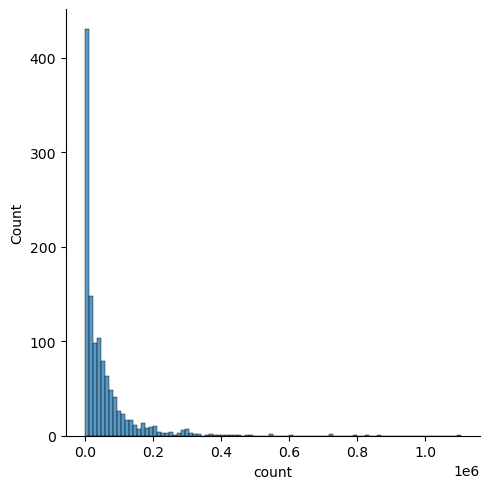

In [26]:
import seaborn as sns
sns.displot(data=target_counts, x='count')

(array([558., 198., 139.,  98.,  55.,  36.,  20.,  20.,  17.,  14.,   6.,
          4.,   9.,   9.,   5.,   1.,   3.,   2.,   2.,   2.,   1.,   1.,
          1.,   0.,   2.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   2.,
          0.,   0.,   0.,   1.,   1.,   0.,   1.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   1.]),
 array([5.20000000e+01, 2.21551800e+04, 4.42583600e+04, 6.63615400e+04,
        8.84647200e+04, 1.10567900e+05, 1.32671080e+05, 1.54774260e+05,
        1.76877440e+05, 1.98980620e+05, 2.21083800e+05, 2.43186980e+05,
        2.65290160e+05, 2.87393340e+05, 3.09496520e+05, 3.31599700e+05,
        3.53702880e+05, 3.75806060e+05, 3.97909240e+05, 4.20012420e+05,
        4.42115600e+05, 4.64218780e+05, 4.86321960e+05, 5.08425140e+05,
        5.30528320e+05, 5.52631500e+05, 5.74734680e+05, 5.96837860e+05,
        6.18941040e+05, 6.41044220e+05, 6.63147400e+05, 6.85250580e+05,
        7.07353760e+05, 7.29456940e+05, 7.51560120e+05, 7.73663300e+05,
        7.

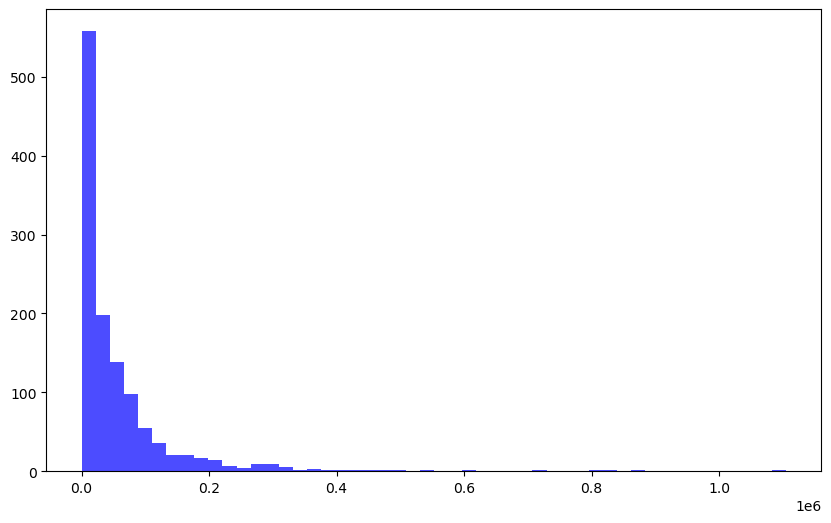

In [23]:
# plot the distribution of the number of TFBS regions per TFBS
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(target_counts['count'], bins=50, color='blue', alpha=0.7)